# 05 · Hybrid VGG16–ResNet50
**Owner:** Kumari Udita (230953094)

The same MRI image goes through **both** frozen backbones. Their globally pooled features
(512 from VGG16, 2,048 from ResNet50) are **concatenated** into one 2,560-value vector, then
the common head Dense(256, ReLU) → Dropout(0.5) → Dense(2, softmax) makes the decision.
The idea (from the source study) is that VGG16's local texture features and ResNet50's deeper
residual features are complementary.

This notebook reuses the cached VGG16 and ResNet50 features from notebooks 03 and 04
(it computes them if they are missing).

In [1]:
import os, sys
os.environ.setdefault("KERAS_BACKEND", "torch")   # Keras 3 backend used for our runs (CPU); "tensorflow" also works
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))        # make the project's src/ package importable

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from src import config, data_pipeline as dp, models, features, training

keras.utils.set_random_seed(config.SEED)
print("Keras", keras.__version__, "| backend:", keras.backend.backend())

Keras 3.15.1 | backend: torch


## One preprocessed image can feed both backbones

In [2]:
from keras.applications import vgg16, resnet50
probe = np.random.default_rng(0).uniform(0, 255, (2, 224, 224, 3)).astype("float32")
same = np.allclose(vgg16.preprocess_input(probe.copy()), resnet50.preprocess_input(probe.copy()))
print("VGG16 and ResNet50 use identical ImageNet preprocessing:", same)

VGG16 and ResNet50 use identical ImageNet preprocessing: True


## Fused features

In [3]:
X_train, y_train, _ = features.load_hybrid_features("train")
X_val, y_val, _ = features.load_hybrid_features("val")
manifest = pd.read_csv(config.SPLIT_MANIFEST)
class_weight = dp.class_weights(manifest)
print("train", X_train.shape, "val", X_val.shape, "| class weights", class_weight)

loaded cached vgg16_train.npz: (4343, 512) (extracted earlier in 14.5 min)


loaded cached resnet50_train.npz: (4343, 2048) (extracted earlier in 9.0 min)


loaded cached vgg16_val.npz: (1086, 512) (extracted earlier in 3.4 min)
loaded cached resnet50_val.npz: (1086, 2048) (extracted earlier in 1.9 min)


train (4343, 2560) val (1086, 2560) | class weights {0: 2.1185365853658538, 1: 0.654460518384569}


## Model

In [4]:
head = models.build_head(models.head_input_dim(["vgg16", "resnet50"]), name="hybrid_head")
full_model = models.assemble_cnn(["vgg16", "resnet50"], head)
full_model.summary()

Model: "vgg16_resnet50_full"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ mri_224x224         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg16_base          │ (None, 512)       │ 14,714,688 │ mri_224x224[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50_base       │ (None, 2048)      │ 23,587,712 │ mri_224x224[0][0] │
│ (Functional)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_fusion      │ (None, 2560)      │          0 │ vgg16_base[0][0], │
│ (Concatenate)       │                   │            │ resnet50_base[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hybrid_head         │ (None, 2)         │    656,130 │ feature_fusion[0… │
│ (Functional)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 38,958,530 (148.61 MB)

 Trainable params: 656,130 (2.50 MB)

 Non-trainable params: 38,302,400 (146.11 MB)

## Train the fusion head

In [5]:
history = training.train(head, X_train, y_train, X_val, y_val,
                         learning_rate=config.HEAD_LR, class_weight=class_weight)

Epoch 1/30


136/136 - 3s - 20ms/step - accuracy: 0.9268 - loss: 0.3717 - val_accuracy: 0.9770 - val_loss: 0.0827


Epoch 2/30


136/136 - 3s - 21ms/step - accuracy: 0.9781 - loss: 0.0727 - val_accuracy: 0.9761 - val_loss: 0.0687


Epoch 3/30


...

136/136 - 3s - 20ms/step - accuracy: 0.9910 - loss: 0.0201 - val_accuracy: 0.9880 - val_loss: 0.0570


Epoch 13/30


136/136 - 4s - 26ms/step - accuracy: 0.9949 - loss: 0.0125 - val_accuracy: 0.9871 - val_loss: 0.0564


Epoch 14/30


136/136 - 1s - 10ms/step - accuracy: 0.9940 - loss: 0.0145 - val_accuracy: 0.9880 - val_loss: 0.0539


## Validation results

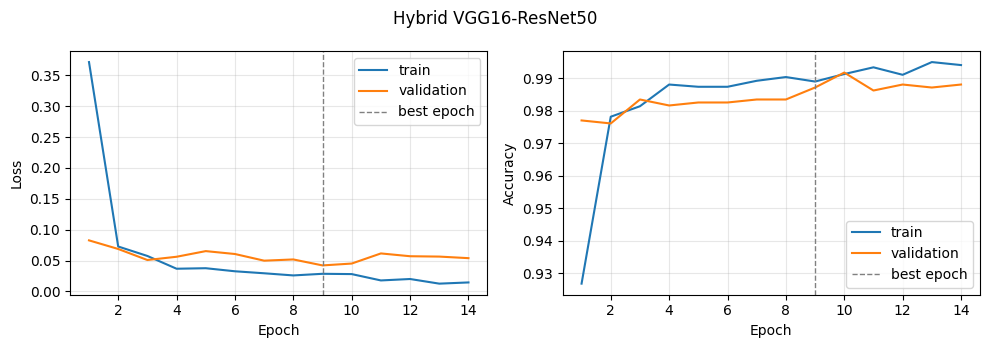

    accuracy: 0.9871
   precision: 0.9892
      recall: 0.9940
 specificity: 0.9648
          f1: 0.9916
    macro_f1: 0.9820
     roc_auc: 0.9991
   confusion: [[TN, FP], [FN, TP]] = [[247, 9], [5, 825]]


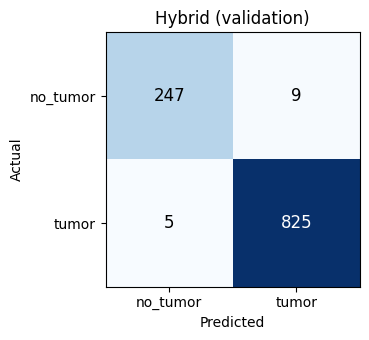

epochs run: 14 | best epoch: 9 | head training time: 32.7 s


In [6]:
training.plot_history(history, "Hybrid VGG16-ResNet50", config.FIG_DIR / "hybrid_curves.png")
metrics, prob, pred = training.evaluate(head, X_val, y_val)
training.print_metrics(metrics)
training.plot_confusion(metrics["confusion_matrix"], "Hybrid (validation)", config.FIG_DIR / "hybrid_confusion.png")
record = training.save_results("hybrid_vgg16_resnet50", metrics, history, head,
                               extra={"total_params_full_model": int(full_model.count_params()),
                                      "learning_rate": config.HEAD_LR})
print("epochs run:", record["epochs_run"], "| best epoch:", record["best_epoch"],
      "| head training time:", record["train_seconds"], "s")

## Sanity check: full hybrid network = cached-feature path

In [7]:
xb, _ = dp.make_cnn_generator("val", vgg16.preprocess_input)[0]
diff = np.abs(full_model.predict(xb[:16], verbose=0) - head.predict(X_val[:16], verbose=0)).max()
print(f"max |difference| in predicted probabilities: {diff:.2e}")

Found 1086 images belonging to 2 classes.


max |difference| in predicted probabilities: 0.00e+00
